# Basic Data Analysis - Student Marks Dataset

## Objective
- Load a student marks dataset using Pandas
- Perform descriptive statistics (mean, median, mode, std dev)
- Visualize score distributions using Matplotlib
- Identify score spread, outliers, and insights
- Analyze Top 10 and Bottom 10 students based on total marks

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
# Loading the dataset
df = pd.read_csv("student_marks.csv")

# Display first 5 rows
df.head()

,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
0,Mr. Gregory Homenick,69,24,52,4,83
1,Marlene Leffler IV,62,59,70,54,52
2,Josephine Ebert,29,76,13,8,19
3,Dr. Irene Green,44,66,14,2,14
4,Jake Huel,49,23,63,86,68


## Basic Info + Null Check

In [3]:
# Dataset shape (rows, columns)
print("Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types and missing values
print("\nDataset Info:")
df.info()

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

Shape: (100, 6)

Columns:
 Index(['student_name', 'maths_marks', 'science_marks', 'english_marks',
       'social_studies_marks', 'language_marks'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_name          100 non-null    str  
 1   maths_marks           100 non-null    int64
 2   science_marks         100 non-null    int64
 3   english_marks         100 non-null    int64
 4   social_studies_marks  100 non-null    int64
 5   language_marks        100 non-null    int64
dtypes: int64(5), str(1)
memory usage: 4.8 KB

Missing values:
 student_name            0
maths_marks             0
science_marks           0
english_marks           0
social_studies_marks    0
language_marks          0
dtype: int64


In [4]:
# Select Only Numeric Columns
# Selecting numeric columns only (marks columns)
numeric_df = df.select_dtypes(include="number")

numeric_df.head()

,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
0,69,24,52,4,83
1,62,59,70,54,52
2,29,76,13,8,19
3,44,66,14,2,14
4,49,23,63,86,68


## Descriptive Statistics (Mean, Median, Mode, Std)

In [5]:
# Mean
mean_values = numeric_df.mean()

# Median
median_values = numeric_df.median()

# Mode
mode_values = numeric_df.mode().iloc[0]

# Standard deviation
std_values = numeric_df.std()

print("Mean:\n", mean_values)
print("\nMedian:\n", median_values)
print("\nMode:\n", mode_values)
print("\nStandard Deviation:\n", std_values)

Mean:
 maths_marks             48.95
science_marks           56.01
english_marks           52.48
social_studies_marks    51.51
language_marks          46.18
dtype: float64

Median:
 maths_marks             52.5
science_marks           59.0
english_marks           51.0
social_studies_marks    52.5
language_marks          42.5
dtype: float64

Mode:
 maths_marks             28
science_marks           48
english_marks           70
social_studies_marks    32
language_marks          31
Name: 0, dtype: int64

Standard Deviation:
 maths_marks             28.999956
science_marks           26.487846
english_marks           27.025420
social_studies_marks    29.081041
language_marks          23.590522
dtype: float64


In [6]:
# Combined Summary Table
summary_stats = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values,
    "Std Dev": std_values
})

summary_stats

,Mean,Median,Mode,Std Dev
maths_marks,48.95,52.5,28,28.999956
science_marks,56.01,59.0,48,26.487846
english_marks,52.48,51.0,70,27.025420
social_studies_marks,51.51,52.5,32,29.081041
language_marks,46.18,42.5,31,23.590522


## Visualizations

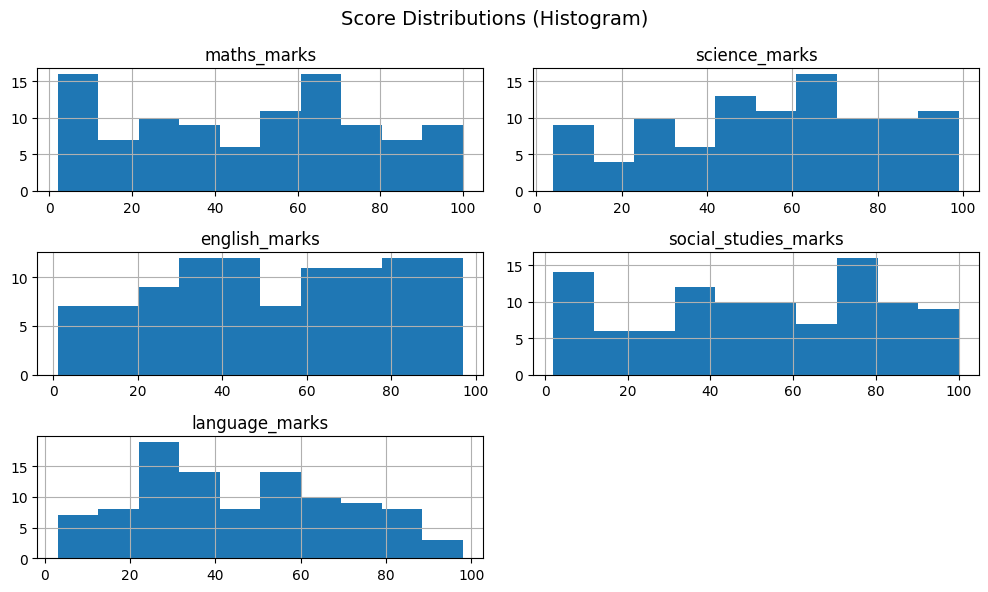

In [7]:
# Histograms (All Subjects)
numeric_df.hist(figsize=(10, 6), bins=10)
plt.suptitle("Score Distributions (Histogram)", fontsize=14)
plt.tight_layout()
plt.savefig("score_histogram.png")
plt.show()

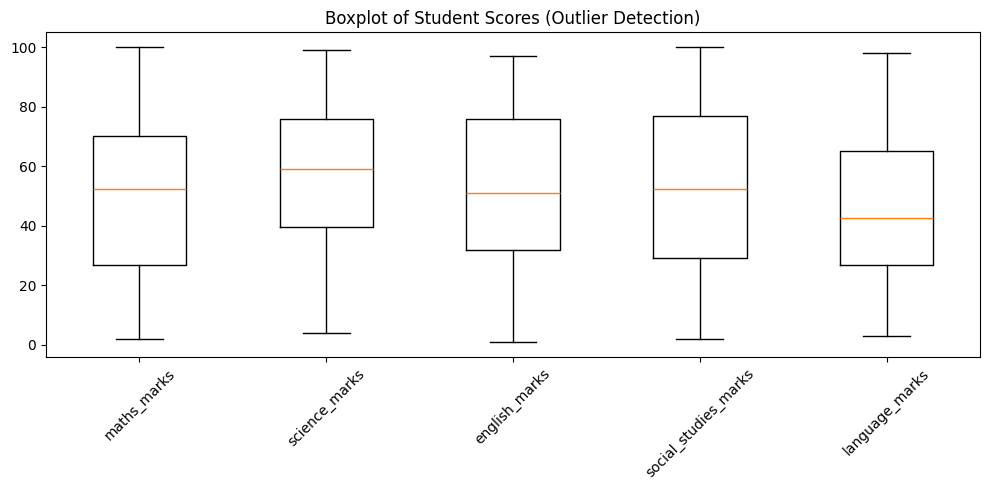

In [8]:
# Boxplot (Outliers)
plt.figure(figsize=(10, 5))
plt.boxplot([numeric_df[col] for col in numeric_df.columns], tick_labels=numeric_df.columns)
plt.title("Boxplot of Student Scores (Outlier Detection)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("boxplot_scores.png")
plt.show()

## Total & Percentage

In [9]:
# Create Total and Percentage Columns
marks_cols = ['maths_marks', 'science_marks', 'english_marks', 'social_studies_marks', 'language_marks']

df["Total"] = df[marks_cols].sum(axis=1)
df["Percentage"] = (df["Total"] / (len(marks_cols) * 100)) * 100

df.head()

,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks,Total,Percentage
0,Mr. Gregory Homenick,69,24,52,4,83,232,46.4
1,Marlene Leffler IV,62,59,70,54,52,297,59.4
2,Josephine Ebert,29,76,13,8,19,145,29.0
3,Dr. Irene Green,44,66,14,2,14,140,28.0
4,Jake Huel,49,23,63,86,68,289,57.8


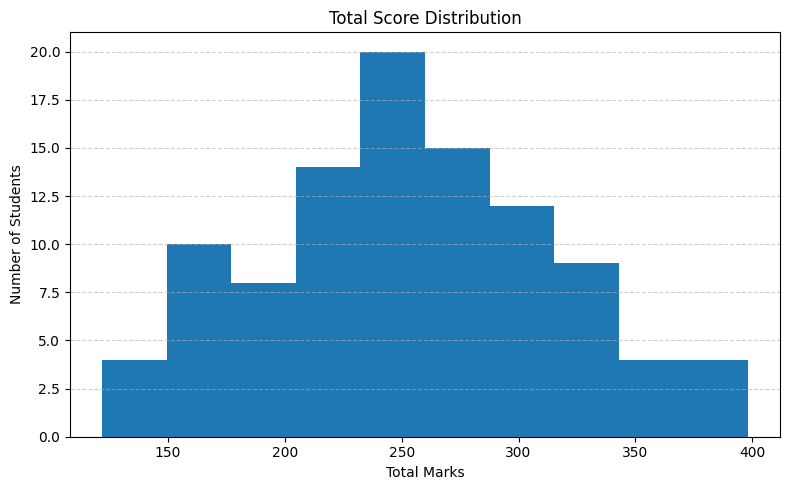

In [10]:
# Total Score Distribution Plot
plt.figure(figsize=(8, 5))
plt.hist(df["Total"], bins=10)
plt.title("Total Score Distribution")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")

# Add gridlines in background
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("total_score_distribution.png")
plt.show()

## Top 10 and Bottom 10 Students Analysis

In [11]:
# Top 10 Students
top_10 = df.sort_values(by="Total", ascending=False).head(10)
top_10[["student_name", "Total", "Percentage"]]

,student_name,Total,Percentage
39,Lowell Bartell,398,79.6
86,Matthew MacGyver,396,79.2
67,Andres Lemke,385,77.0
21,Edith Gorczany,371,74.2
66,Carole Lubowitz,368,73.6
13,Miss Madeline Parisian,367,73.4
48,Mr. Neil Wunsch,363,72.6
87,Marcella Funk,350,70.0
47,Harry Predovic,340,68.0
95,Renee Schinner,335,67.0


In [12]:
# Bottom 10 Students
bottom_10 = df.sort_values(by="Total", ascending=True).head(10)
bottom_10[["student_name", "Total", "Percentage"]]

,student_name,Total,Percentage
18,Conrad Greenholt II,122,24.4
3,Dr. Irene Green,140,28.0
2,Josephine Ebert,145,29.0
58,Hubert Swaniawski,148,29.6
75,Gerardo Kihn,153,30.6
35,Rolando Crona,158,31.6
55,Silvia Dietrich,159,31.8
61,Bob Beier,160,32.0
64,Craig Beatty,168,33.6
28,Mr. Dennis Ledner,168,33.6


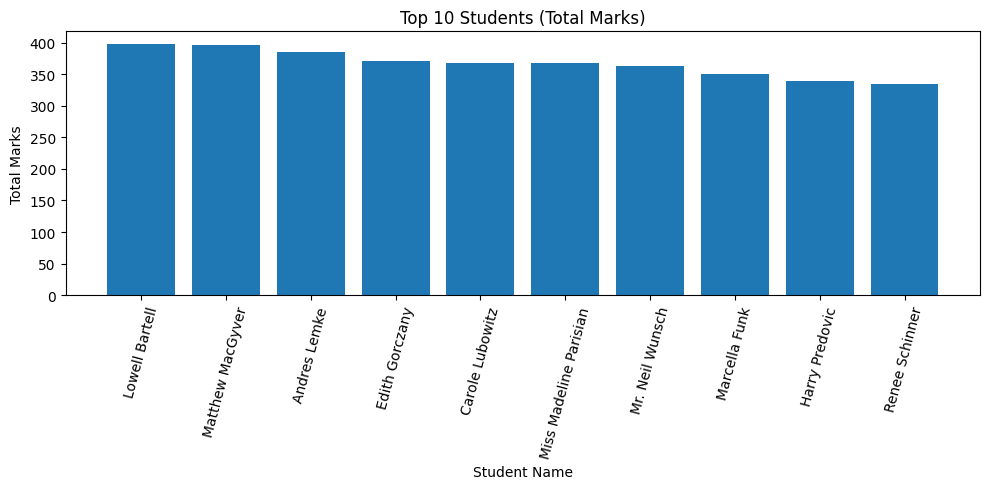

In [13]:
# Top 10 Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(top_10["student_name"], top_10["Total"])
plt.title("Top 10 Students (Total Marks)")
plt.xlabel("Student Name")
plt.ylabel("Total Marks")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("top_10_students.png")
plt.show()

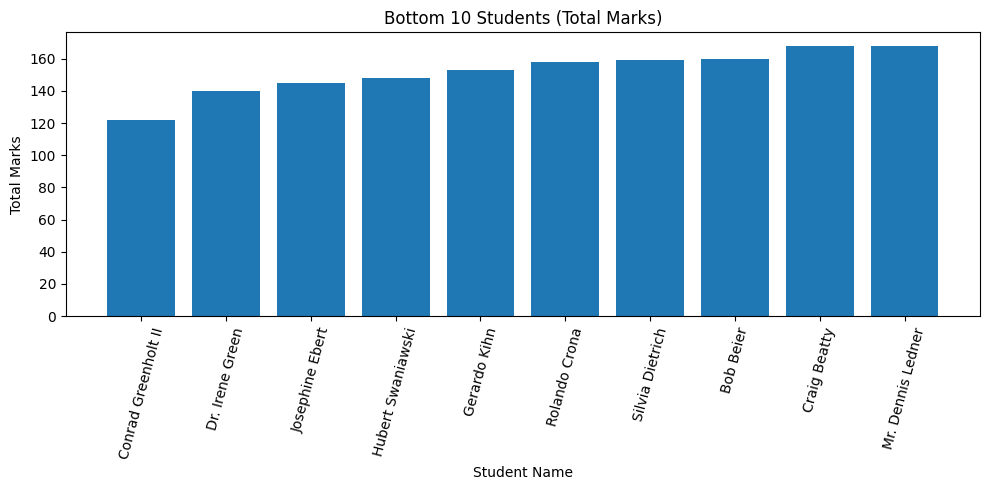

In [14]:
#Bottom 10 Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(bottom_10["student_name"], bottom_10["Total"])
plt.title("Bottom 10 Students (Total Marks)")
plt.xlabel("Student Name")
plt.ylabel("Total Marks")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("bottom_10_students.png")
plt.show()

# => Interpretation and Insights 

## 1) Dataset Overview
- The dataset contains **100 students** and **5 subjects**:
  - Maths, Science, English, Social Studies, Language

---

## 2) Subject-wise Performance (Mean / Average Marks)
The average marks (Mean) in each subject are:

- **Maths:** 48.95  
- **Science:** 56.01  
- **English:** 52.48  
- **Social Studies:** 51.51  
- **Language:** 46.18  

-> **Insight:**  
- Students performed best in **Science (highest mean = 56.01)**  
- Students performed weakest in **Language (lowest mean = 46.18)**  

---

## 3) Median vs Mean (Consistency Check)
Median values:

- **Maths Median:** 52.5  
- **Science Median:** 59
- **English Median:** 51  
- **Social Studies Median:** 52.5  
- **Language Median:** 42.5  

-> **Insight:**  
- Mean and median are close in most subjects → overall performance is fairly balanced.  
- Language median is lower (**42.5**) → many students scored low in Language.

---

## 4) Standard Deviation (Score Spread)
Standard deviation values:

- **Maths:** 28.99  
- **Science:** 26.49  
- **English:** 27.03  
- **Social Studies:** 29.08  
- **Language:** 23.59  

-> **Insight:**  
- Social Studies and Maths have the highest spread → marks vary a lot between students.  
- Language has the lowest spread → most students scored around similar levels.

---

## 5) Total Score Analysis (Overall Performance)
After adding total marks (sum of 5 subjects):

- **Total Mean:** 255.13  
- **Total Median:** 254  
- **Total Standard Deviation:** 62.13  
- **Minimum Total:** 122  
- **Maximum Total:** 398  

-> **Insight:**  
- The average total is **255.13 out of 500**, which is around **51%**.  
- The spread is high (**std dev = 62.13**) meaning student performance varies significantly.  
- The difference between the lowest (122) and highest (398) is large → strong variation exists.

---

## 6) Percentage Analysis
- **Average Percentage:** 51.03%  
- **Median Percentage:** 50.8%  
- **Std Dev of Percentage:** 12.43%  

-> **Insight:**  
Most students are around the **50% range**, but performance varies by about **±12%**.

---

## 7) Outlier Detection
Using the IQR method:

- **Lower Bound:** 89.5  
- **Upper Bound:** 421.5  

-> **Insight:**  
- The minimum total is **122** and maximum total is **398**  
- Both values lie within the bounds  
--> So, **no strong outliers** are detected using IQR for total marks.

---

# => Top 10 Students (Highest Total Marks)

| Rank | Student Name | Total | Percentage |
|------|--------------|-------|------------|
| 1 | Lowell Bartell | 398 | 79.6% |
| 2 | Matthew MacGyver | 396 | 79.2% |
| 3 | Andres Lemke | 385 | 77.0% |
| 4 | Edith Gorczany | 371 | 74.2% |
| 5 | Carole Lubowitz | 368 | 73.6% |
| 6 | Miss Madeline Parisian | 367 | 73.4% |
| 7 | Mr. Neil Wunsch | 363 | 72.6% |
| 8 | Marcella Funk | 350 | 70.0% |
| 9 | Harry Predovic | 340 | 68.0% |
| 10 | Renee Schinner | 335 | 67.0% |

-> **Insight:**  
Top performers scored between **67% to 79.6%**, showing strong consistency across subjects.

---

# => Bottom 10 Students (Lowest Total Marks)

| Rank | Student Name | Total | Percentage |
|------|--------------|-------|------------|
| 1 | Conrad Greenholt II | 122 | 24.4% |
| 2 | Dr. Irene Green | 140 | 28.0% |
| 3 | Josephine Ebert | 145 | 29.0% |
| 4 | Hubert Swaniawski | 148 | 29.6% |
| 5 | Gerardo Kihn | 153 | 30.6% |
| 6 | Rolando Crona | 158 | 31.6% |
| 7 | Silvia Dietrich | 159 | 31.8% |
| 8 | Bob Beier | 160 | 32.0% |
| 9 | Mr. Dennis Ledner | 168 | 33.6% |
| 10 | Craig Beatty | 168 | 33.6% |

-> **Insight:**  
Bottom performers scored between **24.4% to 33.6%**, meaning these students need improvement in multiple subjects.

---

# ==> Final Conclusion
Overall, the dataset shows an average student performance of about **51%**, with noticeable variation between high-performing and low-performing students. Science is the strongest subject on average, while Language is the weakest. Total marks distribution indicates a wide spread, suggesting different learning levels among students. Top 10 students scored close to **80%**, whereas bottom 10 students scored close to **25–35%**, showing a clear performance gap.
